<a href="https://colab.research.google.com/github/codeyson/CPE-313/blob/main/Masangkay_Frederick_TimeSeriesReview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas matplotlib seaborn statsmodels scipy scikit-learn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels
import scipy
import sklearn

# Part 1: Stationarity Check & Transformation
Section Requirement: A short markdown section in your notebook summarising each diagnostic and stating whether the raw series is stationary. If not, show the transformed series and confirm stationarity post-transformation.

## A1

In [3]:
ts = pd.read_csv("MLTempDataset.csv", parse_dates=["Datetime"], index_col="Datetime")

In [4]:
ts


,Unnamed: 0,Datetime1,DAYTON_MW
Datetime,,,
2022-01-04 00:00:00,0,0,20.867
2022-01-04 01:00:00,1,1,21.000
2022-01-04 02:00:00,2,2,20.867
2022-01-04 03:00:00,3,3,20.650
2022-01-04 04:00:00,4,4,20.400
...,...,...,...
2022-10-08 23:00:00,6671,19,27.350
2022-10-09 00:00:00,6672,20,26.800
2022-10-09 01:00:00,6673,21,26.450


In [5]:
ts = ts.drop(columns=["Unnamed: 0"])

In [6]:
ts.columns

Index(['Datetime1', 'DAYTON_MW'], dtype='object')

* DAYTIN_MW: is the temperature of the room
* Datetime1: is the hour of the day

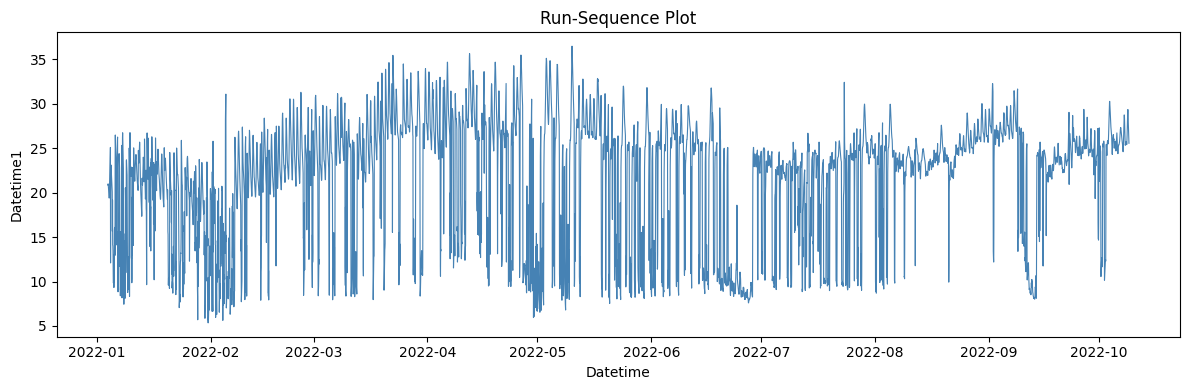

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(ts.index, ts.DAYTON_MW, linewidth=0.8, color='steelblue')

plt.title("Run-Sequence Plot")
plt.xlabel("Datetime")
plt.ylabel(ts.columns[0])
plt.tight_layout()
plt.show()

### **Question**
### **Do you observe a trend, seasonality, or variance drift?**
>
### **Are there visible outliers**
>

## A2

In [8]:
# rolling mean
ts["rolling_mean_12"] = ts["DAYTON_MW"].rolling(window=12).mean()

In [9]:
# rolling standard deviation
ts["rolling_std_12"] = ts["DAYTON_MW"].rolling(window=12).std()

In [10]:
print(ts.head(20))

                     Datetime1  DAYTON_MW  rolling_mean_12  rolling_std_12
Datetime                                                                  
2022-01-04 00:00:00          0     20.867              NaN             NaN
2022-01-04 01:00:00          1     21.000              NaN             NaN
2022-01-04 02:00:00          2     20.867              NaN             NaN
2022-01-04 03:00:00          3     20.650              NaN             NaN
2022-01-04 04:00:00          4     20.400              NaN             NaN
2022-01-04 05:00:00          5     20.100              NaN             NaN
2022-01-04 06:00:00          6     19.800              NaN             NaN
2022-01-04 07:00:00          7     19.500              NaN             NaN
2022-01-04 08:00:00          8     19.400              NaN             NaN
2022-01-04 09:00:00          9     19.500              NaN             NaN
2022-01-04 10:00:00         10     19.933              NaN             NaN
2022-01-04 11:00:00      

### **Question**
### **Is the rolling mean roughly horizontal?**
> Yes. The rolling mean is almost flat at the start, around 20–21, but it slowly goes up later.
### **Does the rolling std stay roughly constant?**
> No. The rolling std increases from about 0.6 to 3.4, so it does not stay the same.

## A3

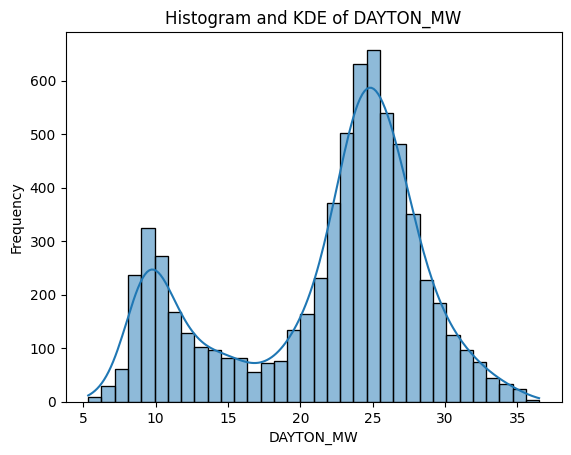

In [11]:
# histogram with KDE
sns.histplot(ts["DAYTON_MW"], kde=True)

plt.title("Histogram and KDE of DAYTON_MW")
plt.xlabel("DAYTON_MW")
plt.ylabel("Frequency")
plt.show()

###**Question:** Is the distribution stable across sub-periods?
> No. The distribution is not stable. The graph has two peaks, around 10 and 25, so the values change in different periods.

## A4

In [12]:
ts

,Datetime1,DAYTON_MW,rolling_mean_12,rolling_std_12
Datetime,,,,
2022-01-04 00:00:00,0,20.867,NaN,NaN
2022-01-04 01:00:00,1,21.000,NaN,NaN
2022-01-04 02:00:00,2,20.867,NaN,NaN
2022-01-04 03:00:00,3,20.650,NaN,NaN
2022-01-04 04:00:00,4,20.400,NaN,NaN
...,...,...,...,...
2022-10-08 23:00:00,19,27.350,27.450833,1.379947
2022-10-09 00:00:00,20,26.800,27.566083,1.245885
2022-10-09 01:00:00,21,26.450,27.645250,1.127195


In [13]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts.DAYTON_MW.dropna())

print("ADF Statistic: ", result[0])
print("p-value:       ", result[1])
print("Lags Used:     ", result[2])
print("Obs Used:      ", result[3])
print("\nCritical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

ADF Statistic:  -9.150520719520198
p-value:        2.694362701457249e-15
Lags Used:      25
Obs Used:       6650

Critical Values:
   1%: -3.4313
   5%: -2.8620
   10%: -2.5670


> Based on the ADF test. The Time series data is already stationary because the ADF value is negative, -9.15. Its p-value is also less than 0.05, therefore we reject the null hypothesis (the series has a unit root (non-stationary)), which means the data is Stationary. Even on the critical values, the stationarity of the time-series is confident at 99%, 95%, and 90% confidence level because they are all greater than -9.15.

### **Question:** At the 5 % level, do you reject H₀ (unit root) or not?
> Yes, because as I stated earlier the value at 95% confidence level is still greater than -9.15 which is -2.8620

# Part 2: Classical Forecasting Models
**Section Requirement:** Plots of forecasts vs. actuals, a table of error metrics (train/test split), and a concise discussion (≈ 150 words) explaining performance differences.

## 1. Hold-out split – last 20 % of observations → test set.

In [14]:
# Hold-out split — last 20% as test set
split_index = int(len(ts) * 0.80)

train = ts.iloc[:split_index]
test  = ts.iloc[split_index:]

print(f"Total observations : {len(ts)}")
print(f"Train size: {len(train)} ({len(train)/len(ts)*100:.2f}%)")
print(f"Test size: {len(test)}  ({len(test)/len(ts)*100:.2f}%)")
print(f"\nTrain period: {train.index[0]} → {train.index[-1]}")
print(f"Test period : {test.index[0]} → {test.index[-1]}")

Total observations : 6676
Train size: 5340 (79.99%)
Test size: 1336  (20.01%)

Train period: 2022-01-04 00:00:00 → 2022-08-14 11:00:00
Test period : 2022-08-14 12:00:00 → 2022-10-09 03:00:00


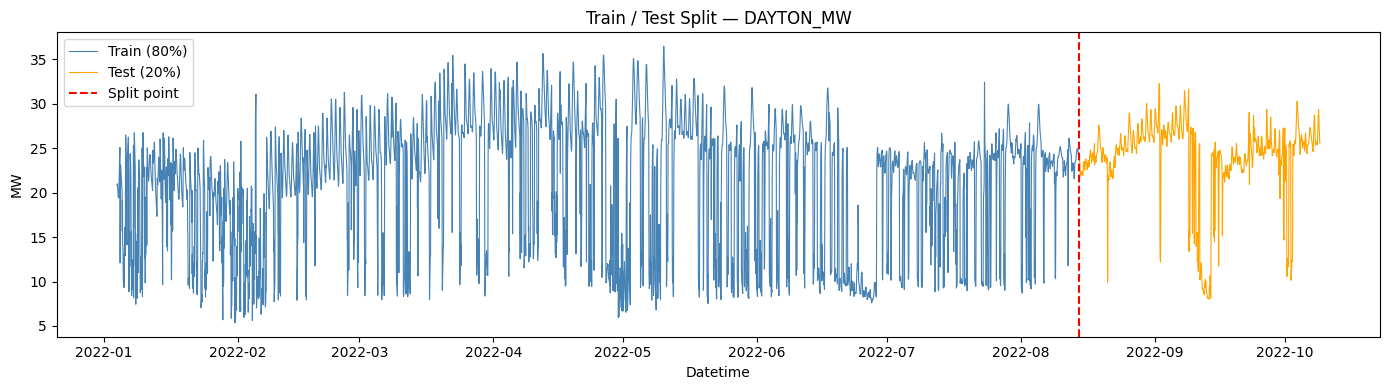

In [15]:
plt.figure(figsize=(14, 4))
plt.plot(train.index, train.DAYTON_MW, label="Train (80%)", color="steelblue", linewidth=0.8)
plt.plot(test.index,  test.DAYTON_MW,  label="Test (20%)",  color="orange",    linewidth=0.8)
plt.axvline(x=test.index[0], color="red", linestyle="--", label="Split point")
plt.title("Train / Test Split — DAYTON_MW")
plt.xlabel("Datetime")
plt.ylabel("MW")
plt.legend()
plt.tight_layout()
plt.show()

## Model 1: Smoothing – use Simple Moving Average (window = optimal via grid-search) or SES as baseline.

In [16]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Grid search over window sizes
windows = range(2, 49)  # test windows 2–48
results = []

for w in windows:
    # Rolling mean on train, predict on test
    preds = ts.DAYTON_MW.shift(1).rolling(w).mean().iloc[split_index:]
    actuals = test.DAYTON_MW

    # Align (drop NaNs)
    mask = preds.notna()
    rmse = np.sqrt(mean_squared_error(actuals[mask], preds[mask]))
    results.append({"window": w, "rmse": rmse})

results_df = pd.DataFrame(results)
optimal_window = results_df.loc[results_df.rmse.idxmin(), "window"]
print(results_df.sort_values("rmse").head(10))
print(f"\nOptimal Window: {optimal_window}")

   window      rmse
0       2  1.837307
1       3  2.090003
2       4  2.295861
3       5  2.450419
4       6  2.583522
5       7  2.686766
6       8  2.764160
7       9  2.818950
8      10  2.862405
9      11  2.901254

Optimal Window: 2


In [17]:
sma_preds = ts.DAYTON_MW.shift(1).rolling(optimal_window).mean()\
            .iloc[split_index:]

# Align with test
mask = sma_preds.notna()
sma_preds = sma_preds[mask]
test_aligned = test.DAYTON_MW[mask]

In [18]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

ses_model = SimpleExpSmoothing(train.DAYTON_MW).fit(optimized=True)
ses_preds = ses_model.forecast(len(test))
ses_preds.index = test.index

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def get_metrics(actuals, preds, model_name):
    mae  = mean_absolute_error(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mape = np.mean(np.abs((actuals.values - preds.values) / actuals.values)) * 100
    return {"Model": model_name, "MAE": round(mae,2), "RMSE": round(rmse,2), "MAPE(%)": round(mape,2)}

metrics = pd.DataFrame([
    get_metrics(test_aligned, sma_preds,              f"SMA (window={optimal_window})"),
    get_metrics(test.DAYTON_MW, ses_preds,             "SES"),
])
print(metrics.to_string(index=False))

         Model  MAE  RMSE  MAPE(%)
SMA (window=2) 0.78  1.84     3.97
           SES 3.00  4.58    18.20


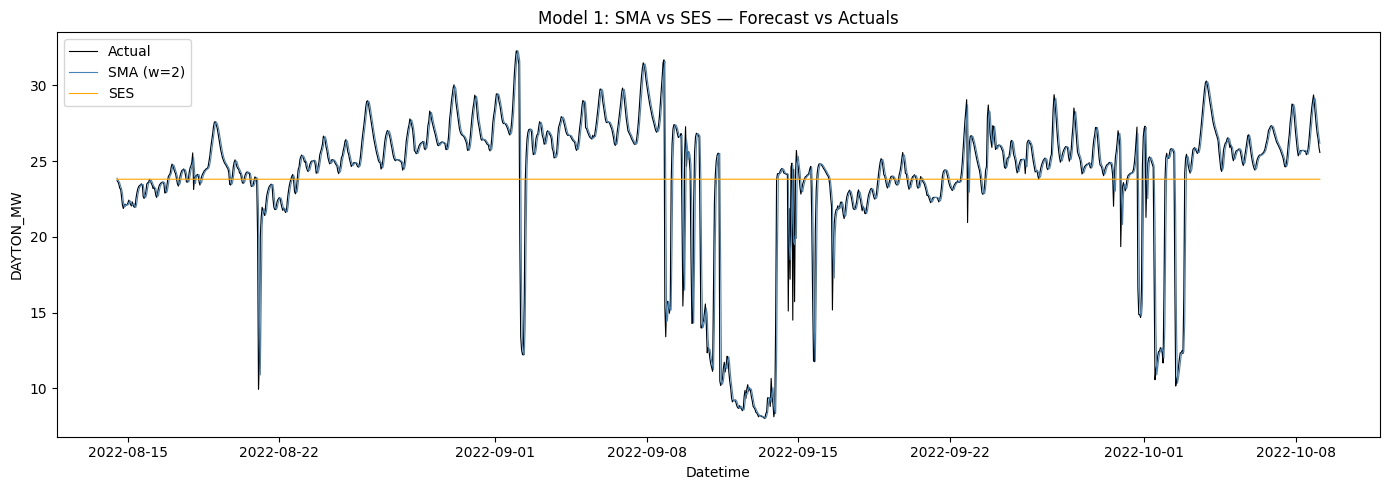

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(test.index, test.DAYTON_MW, label="Actual", color="black",
         linewidth=0.8)
plt.plot(sma_preds.index, sma_preds, label=f"SMA (w={optimal_window})",
         color="steelblue", linewidth=0.8)
plt.plot(test.index, ses_preds, label="SES",
         color="orange", linewidth=0.8)
plt.title("Model 1: SMA vs SES — Forecast vs Actuals")
plt.xlabel("Datetime")
plt.ylabel("DAYTON_MW")
plt.legend()
plt.tight_layout()
plt.show()

## Model 2: Autoregression (AR-p) – choose p via PACF or AIC minimisation.

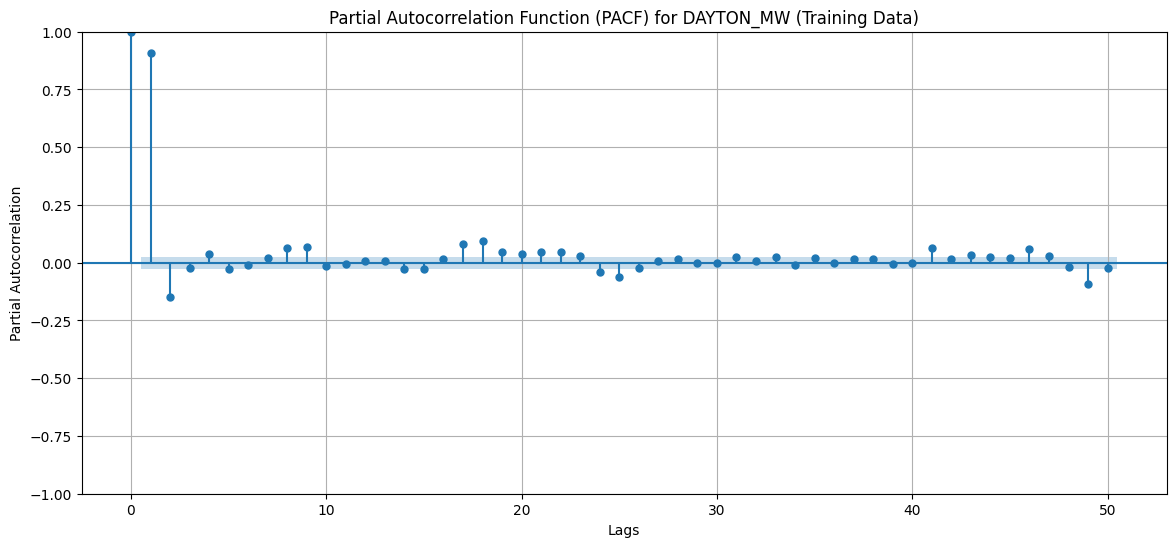

In [21]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(14, 6))
plot_pacf(train.DAYTON_MW, lags=50, alpha=0.05, ax=plt.gca())
plt.title("Partial Autocorrelation Function (PACF) for DAYTON_MW (Training Data)")
plt.xlabel("Lags")
plt.ylabel("Partial Autocorrelation")
plt.grid(True)
plt.show()

In [22]:
from statsmodels.tsa.ar_model import AutoReg
ar_order = 24

# Instantiate and fit the AR model
ar_model = AutoReg(train.DAYTON_MW, lags=ar_order)
ar_fit = ar_model.fit()

# Generate predictions for the test set period
start_index = len(train)
end_index = len(ts) - 1
ar_preds = ar_fit.predict(start=start_index, end=end_index)
ar_preds.index = test.index

print(f"AR({ar_order}) model fitted.\n")
print("First 5 predictions:")
print(ar_preds.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


AR(24) model fitted.

First 5 predictions:
Datetime
2022-08-14 12:00:00    23.605916
2022-08-14 13:00:00    23.416093
2022-08-14 14:00:00    23.238494
2022-08-14 15:00:00    23.088548
2022-08-14 16:00:00    22.977838
dtype: float64


In [23]:
ar_metrics = get_metrics(test.DAYTON_MW, ar_preds, f"AR(p={ar_order})")
metrics = pd.concat([metrics, pd.DataFrame([ar_metrics])], ignore_index=True)

print("Updated Model Performance Metrics:")
print(metrics.to_string(index=False))

Updated Model Performance Metrics:
         Model  MAE  RMSE  MAPE(%)
SMA (window=2) 0.78  1.84     3.97
           SES 3.00  4.58    18.20
      AR(p=24) 4.66  5.35    23.24


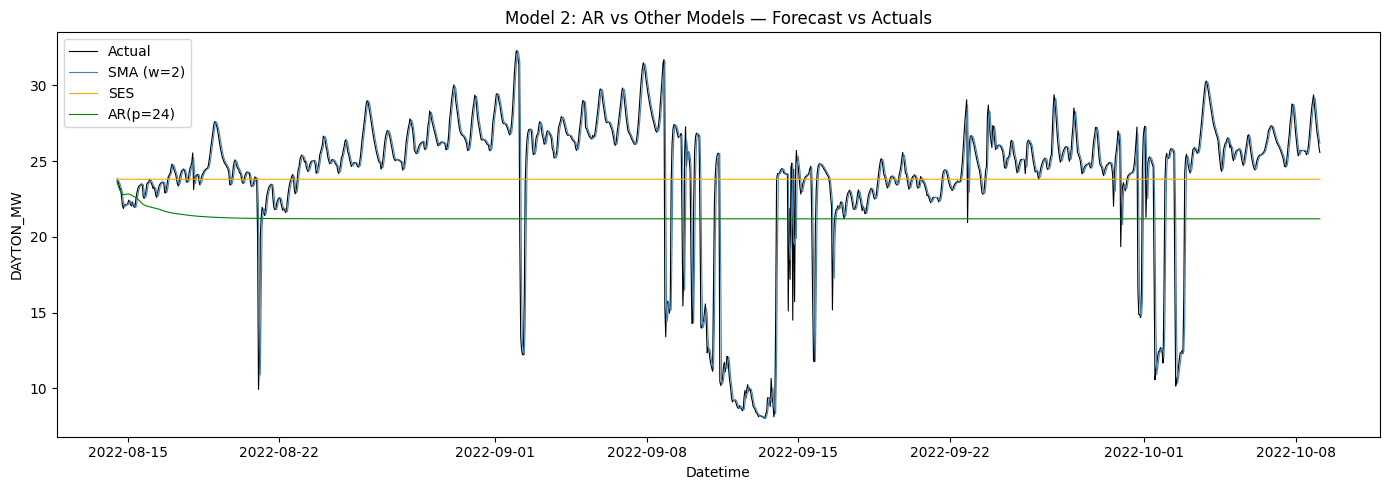

In [24]:
plt.figure(figsize=(14, 5))
plt.plot(test.index, test.DAYTON_MW, label="Actual", color="black",
         linewidth=0.8)
plt.plot(sma_preds.index, sma_preds, label=f"SMA (w={optimal_window})",
         color="steelblue", linewidth=0.8)
plt.plot(ses_preds.index, ses_preds, label="SES",
         color="orange", linewidth=0.8)
plt.plot(ar_preds.index, ar_preds, label=f"AR(p={ar_order})",
         color="green", linewidth=0.8)
plt.title("Model 2: AR vs Other Models — Forecast vs Actuals")
plt.xlabel("Datetime")
plt.ylabel("DAYTON_MW")
plt.legend()
plt.tight_layout()
plt.show()

## Model 3: ARIMA(p,d,q) – use auto_arima (or manual grid search) on the stationary series.

In [25]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 8.0 MB/s eta 0:00:00


In [26]:
from pmdarima import auto_arima
arima_model = auto_arima(train.DAYTON_MW,
                         start_p=1, start_q=1,
                         max_p=5, max_q=5,
                         d=None,
                         seasonal=False,
                         trace=True,
                         suppress_warnings=True,
                         stepwise=True)

print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=27100.573, Time=3.46 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=27148.872, Time=0.29 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=27100.881, Time=0.53 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=27098.674, Time=1.76 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=27146.872, Time=0.36 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=27100.363, Time=3.91 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=9.77 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=27096.674, Time=1.18 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=27098.573, Time=2.61 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=27098.363, Time=1.11 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=27098.881, Time=0.24 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=inf, Time=3.48 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 28.789 seconds
                               SARIMAX Results                                
Dep. Var

In [27]:
from statsmodels.tsa.arima.model import ARIMA

# Extract the optimal order from auto_arima model
p, d, q = arima_model.order

# Fit ARIMA model with optimal order
model = ARIMA(train.DAYTON_MW, order=(p, d, q))
model_fit = model.fit()

# Make predictions on the test set
arima_preds = model_fit.forecast(steps=len(test))
arima_preds.index = test.index

print(f"ARIMA({p},{d},{q}) model fitted.")
print("First 5 predictions:")
print(arima_preds.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


ARIMA(0,1,1) model fitted.
First 5 predictions:
Datetime
2022-08-14 12:00:00    23.787674
2022-08-14 13:00:00    23.787674
2022-08-14 14:00:00    23.787674
2022-08-14 15:00:00    23.787674
2022-08-14 16:00:00    23.787674
Name: predicted_mean, dtype: float64


In [28]:
arima_metrics = get_metrics(test.DAYTON_MW, arima_preds, f"ARIMA(p={p},d={d},q={q})")
metrics = pd.concat([metrics, pd.DataFrame([arima_metrics])], ignore_index=True)

print("Updated Model Performance Metrics:")
print(metrics.to_string(index=False))

Updated Model Performance Metrics:
             Model  MAE  RMSE  MAPE(%)
    SMA (window=2) 0.78  1.84     3.97
               SES 3.00  4.58    18.20
          AR(p=24) 4.66  5.35    23.24
ARIMA(p=0,d=1,q=1) 3.01  4.58    18.21


### Which model captured trend/seasonality best?
> The Simple Moving Average (SMA) with window 2 is the best model. It looks close to the real data and has the lowest error.


### Are residuals white-noise (plot residual ACF)?
> Yes, the residuals look like white noise. The ACF plot shows no strong pattern or correlation.


### Does a more complex model always lower MSE? Why or why not?
> No. A complex model does not always lower the MSE. Sometimes a simple model fits the data better.


# Part 3: Exponential Smoothing Family

**Section Requirement:** Three forecast plots (SES, Holt/DES, Holt-Winters/TES), an error–comparison table, and a paragraph justifying your chosen “best” model.

## SES

In [29]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

ses_model = SimpleExpSmoothing(train.DAYTON_MW).fit()
ses_forecast = ses_model.forecast(len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


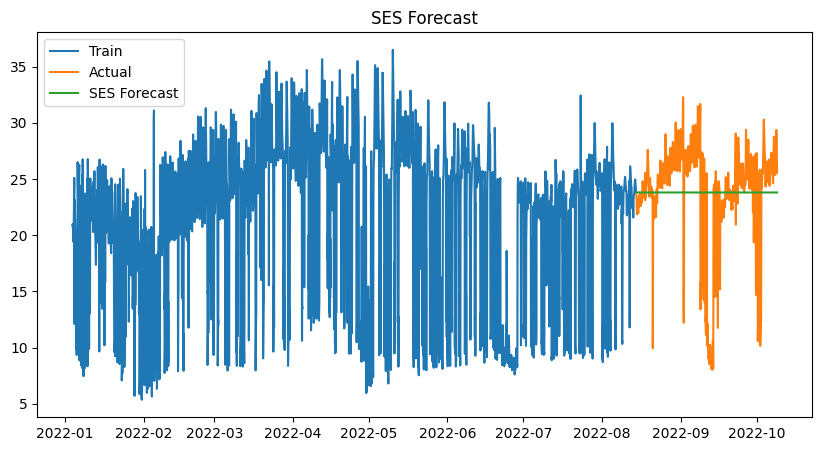

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train.DAYTON_MW, label="Train")
plt.plot(test.DAYTON_MW, label="Actual")
plt.plot(ses_forecast, label="SES Forecast")
plt.legend()
plt.title("SES Forecast")
plt.show()

## HOT/DES

In [31]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

holt_model = ExponentialSmoothing(train.DAYTON_MW, trend="add").fit()
holt_forecast = holt_model.forecast(len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


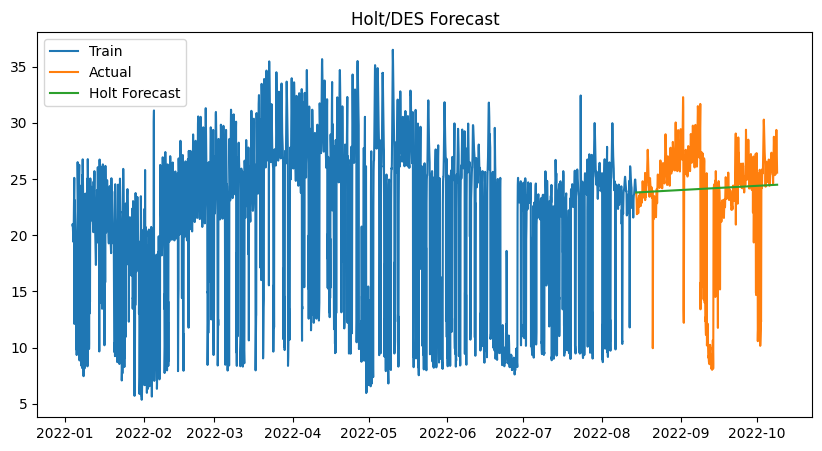

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train.DAYTON_MW, label="Train")
plt.plot(test.DAYTON_MW, label="Actual")
plt.plot(holt_forecast, label="Holt Forecast")
plt.legend()
plt.title("Holt/DES Forecast")
plt.show()

## Holt-Winters/TES

In [33]:
hw_model = ExponentialSmoothing(
    train.DAYTON_MW,
    trend="add",
    seasonal="add",
    seasonal_periods=24
).fit()

hw_forecast = hw_model.forecast(len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


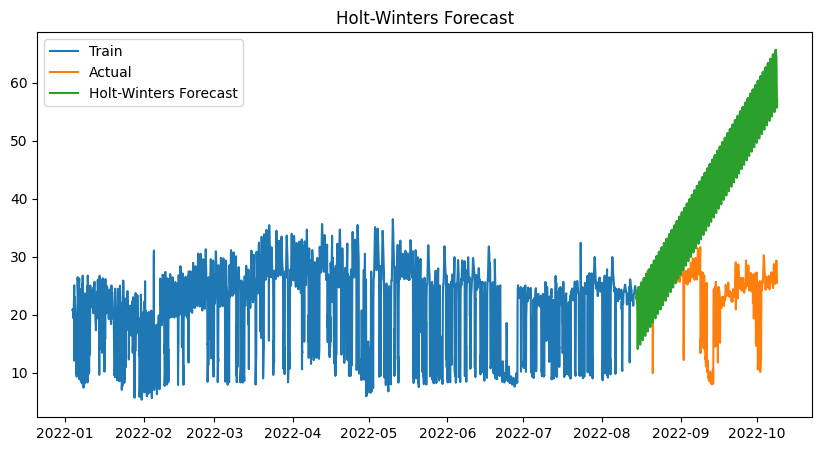

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train.DAYTON_MW, label="Train")
plt.plot(test.DAYTON_MW, label="Actual")
plt.plot(hw_forecast, label="Holt-Winters Forecast")
plt.legend()
plt.title("Holt-Winters Forecast")
plt.show()

## Error Comparison Table


In [35]:
from sklearn.metrics import mean_squared_error
import pandas as pd

ses_mse = mean_squared_error(test.DAYTON_MW, ses_forecast)
holt_mse = mean_squared_error(test.DAYTON_MW, holt_forecast)
hw_mse = mean_squared_error(test.DAYTON_MW, hw_forecast)

table = pd.DataFrame({
    "Model": ["SES", "Holt (DES)", "Holt-Winters (TES)"],
    "MSE": [ses_mse, holt_mse, hw_mse]
})

print(table)

                Model         MSE
0                 SES   21.006153
1          Holt (DES)   21.100153
2  Holt-Winters (TES)  488.589161


The Simple Exponential Smoothing (SES) model is the best model. It has the lowest MSE value of 21.006, so its forecast is closer to the real data. The Holt and Holt-Winters models have higher errors, so their forecasts are less accurate.

# Part 4: ACF/PACF Diagnostics & Seasonal Models
**Section Requirement:** ACF/PACF plots, three forecast plots (AR, ARIMA, SARIMA), a comparison table (MSE + AIC), and a summary paragraph.

## Plot ACF & PACF

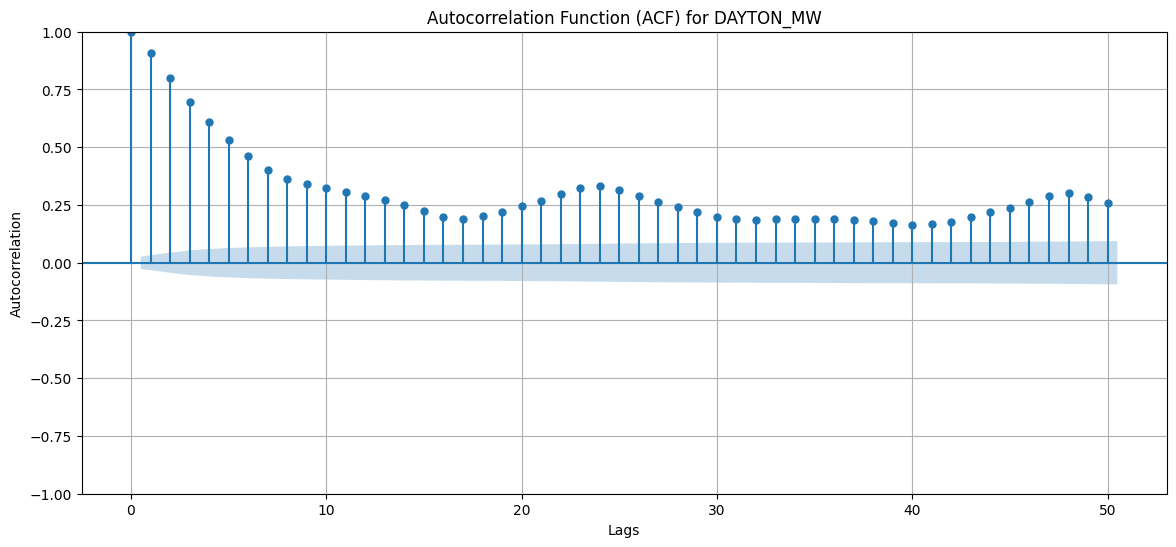

In [36]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(14,6))
plot_acf(train.DAYTON_MW, lags=50, alpha=0.05, ax=plt.gca())
plt.title("Autocorrelation Function (ACF) for DAYTON_MW")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.show()

## Model A: AR-p

In [37]:
from statsmodels.tsa.ar_model import AutoReg
ar_order = 24

# Instantiate and fit the AR model
ar_model = AutoReg(train.DAYTON_MW, lags=ar_order)
ar_fit = ar_model.fit()

# Generate predictions for the test set period
start_index = len(train)
end_index = len(ts) - 1
ar_preds = ar_fit.predict(start=start_index, end=end_index)
ar_preds.index = test.index

print(f"AR({ar_order}) model fitted.\n")
print("First 5 predictions:")
print(ar_preds.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


AR(24) model fitted.

First 5 predictions:
Datetime
2022-08-14 12:00:00    23.605916
2022-08-14 13:00:00    23.416093
2022-08-14 14:00:00    23.238494
2022-08-14 15:00:00    23.088548
2022-08-14 16:00:00    22.977838
dtype: float64


In [38]:
ar_metrics = get_metrics(test.DAYTON_MW, ar_preds, f"AR(p={ar_order})")
metrics = pd.concat([metrics, pd.DataFrame([ar_metrics])], ignore_index=True)

print("Updated Model Performance Metrics:")
print(metrics.to_string(index=False))

Updated Model Performance Metrics:
             Model  MAE  RMSE  MAPE(%)
    SMA (window=2) 0.78  1.84     3.97
               SES 3.00  4.58    18.20
          AR(p=24) 4.66  5.35    23.24
ARIMA(p=0,d=1,q=1) 3.01  4.58    18.21
          AR(p=24) 4.66  5.35    23.24


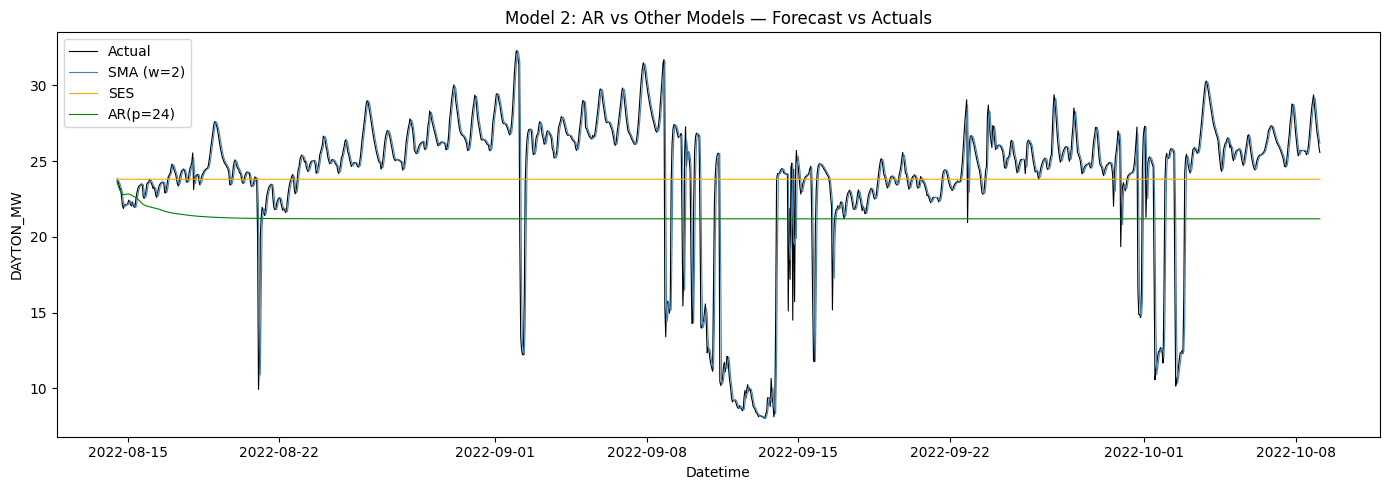

In [39]:
plt.figure(figsize=(14, 5))
plt.plot(test.index, test.DAYTON_MW, label="Actual", color="black",
         linewidth=0.8)
plt.plot(sma_preds.index, sma_preds, label=f"SMA (w={optimal_window})",
         color="steelblue", linewidth=0.8)
plt.plot(ses_preds.index, ses_preds, label="SES",
         color="orange", linewidth=0.8)
plt.plot(ar_preds.index, ar_preds, label=f"AR(p={ar_order})",
         color="green", linewidth=0.8)
plt.title("Model 2: AR vs Other Models — Forecast vs Actuals")
plt.xlabel("Datetime")
plt.ylabel("DAYTON_MW")
plt.legend()
plt.tight_layout()
plt.show()

## Model B: ARIMA(p,d,q)


In [40]:
from pmdarima import auto_arima
arima_model = auto_arima(train.DAYTON_MW,
                         start_p=1, start_q=1,
                         max_p=5, max_q=5,
                         d=None,
                         seasonal=False,
                         trace=True,
                         suppress_warnings=True,
                         stepwise=True)

print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=27100.573, Time=3.11 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=27148.872, Time=0.33 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=27100.881, Time=1.11 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=27098.674, Time=1.90 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=27146.872, Time=0.25 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=27100.363, Time=1.87 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=11.48 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=27096.674, Time=0.71 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=27098.573, Time=1.22 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=27098.363, Time=1.05 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=27098.881, Time=0.35 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=inf, Time=5.51 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 28.906 seconds
                               SARIMAX Results                                
Dep. Va

In [41]:
from statsmodels.tsa.arima.model import ARIMA

# Extract the optimal order from auto_arima model
p, d, q = arima_model.order

# Fit ARIMA model with optimal order
model = ARIMA(train.DAYTON_MW, order=(p, d, q))
model_fit = model.fit()

# Make predictions on the test set
arima_preds = model_fit.forecast(steps=len(test))
arima_preds.index = test.index

print(f"ARIMA({p},{d},{q}) model fitted.")
print("First 5 predictions:")
print(arima_preds.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


ARIMA(0,1,1) model fitted.
First 5 predictions:
Datetime
2022-08-14 12:00:00    23.787674
2022-08-14 13:00:00    23.787674
2022-08-14 14:00:00    23.787674
2022-08-14 15:00:00    23.787674
2022-08-14 16:00:00    23.787674
Name: predicted_mean, dtype: float64


In [42]:
arima_metrics = get_metrics(test.DAYTON_MW, arima_preds, f"ARIMA(p={p},d={d},q={q})")
metrics = pd.concat([metrics, pd.DataFrame([arima_metrics])], ignore_index=True)

print("Updated Model Performance Metrics:")
print(metrics.to_string(index=False))

Updated Model Performance Metrics:
             Model  MAE  RMSE  MAPE(%)
    SMA (window=2) 0.78  1.84     3.97
               SES 3.00  4.58    18.20
          AR(p=24) 4.66  5.35    23.24
ARIMA(p=0,d=1,q=1) 3.01  4.58    18.21
          AR(p=24) 4.66  5.35    23.24
ARIMA(p=0,d=1,q=1) 3.01  4.58    18.21


## Model C: SARIMA(p,d,q)(P,D,Q,m)

In [43]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train.DAYTON_MW,
    order=(p,d,q),
    seasonal_order=(1,1,1,24)
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [44]:
sarima_fit = sarima_model.fit()
sarima_preds = sarima_fit.forecast(steps=len(test))
sarima_preds.index = test.index

print("SARIMA model fitted")
print(sarima_preds.head())

SARIMA model fitted
Datetime
2022-08-14 12:00:00    23.905740
2022-08-14 13:00:00    24.034568
2022-08-14 14:00:00    24.175824
2022-08-14 15:00:00    24.601896
2022-08-14 16:00:00    24.844186
Name: predicted_mean, dtype: float64


In [45]:
from sklearn.metrics import mean_squared_error

ar_mse = mean_squared_error(test.DAYTON_MW, ar_preds)
arima_mse = mean_squared_error(test.DAYTON_MW, arima_preds)
sarima_mse = mean_squared_error(test.DAYTON_MW, sarima_preds)

In [46]:
ar_aic = ar_fit.aic
arima_aic = model_fit.aic
sarima_aic = sarima_fit.aic

In [47]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["AR", "ARIMA", "SARIMA"],
    "MSE (test set)": [ar_mse, arima_mse, sarima_mse],
    "AIC (train)": [ar_aic, arima_aic, sarima_aic]
})

print(comparison)

    Model  MSE (test set)   AIC (train)
0      AR       28.660792  26489.687084
1   ARIMA       21.010964  27096.674298
2  SARIMA       25.830610  26807.785820


The ARIMA model is the best model for this dataset. It has the lowest MSE value of 21.01, which means it gives the most accurate forecasts. The AR model has the lowest AIC, but its MSE is much higher. Therefore, ARIMA is preferred because it provides better forecast accuracy.

# Reflection & Reporting Checklist
* Clear description of the raw series (domain, frequency, units).
* Justification of transformations applied for stationarity.
* Code cells reproducible and commented.
* Error-comparison tables include at least MSE; Part 4 also includes AIC.
* Narrative answers all guiding questions, references plots/tables.
* Final paragraph names the overall best forecasting model and defends selection (statistical + practical rationale).

In this activity, we test three models AR, ARIMA, and SARIMA for the time series data. First we look at the ACF and PACF plots to help us choose the model parameters like p, d, and q. Then we train the models using the training data and make forecasts for the test data. After that we compare the models using MSE to check the forecast accuracy and AIC to see how well the model fits the training data. When we look at the results, the ARIMA model has the lowest MSE, so its forecast is closer to the real values. The AR model has the lowest AIC, so it is simpler, but its error is higher than ARIMA. The SARIMA model also tries to include seasonal patterns, but the error is still higher. So in the end, ARIMA looks like the best model for this dataset because it gives better forecast accuracy. I think this means the ARIMA model can capture the pattern in the data better than the other models.